## STUDENT'S ACEDAMIC PERFORMANCE(ED TECH COMPANY)

The Problem Statement

"To identify the key demographic, social, and behavioral factors that significantly impact student academic performance (Math, Reading, and Writing) in order to develop targeted intervention strategies for underperforming student groups."

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('Expanded_data_with_more_features.csv')

### Data Description

In [4]:
#no. of rows and col
df.shape

(30641, 15)

In [5]:
#print first 5 rows with all col
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [6]:
#datatypes of col, count of not null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [7]:
#count of null values in an col
df.isnull().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

### Droping Unnamed Col

In [8]:
#unnamed col acts as index, redundant data = drop
df = df.drop("Unnamed: 0",axis=1)

### Modifying weekly study hours col

In [9]:
# filling nan values in testprep col with none
df["TestPrep"]=df["TestPrep"].fillna("unknown")

In [10]:
#modifying weekly study hours col
df["WklyStudyHours"] = df["WklyStudyHours"].str.replace("05-Oct","05-10")
df.sample(7)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
19060,male,group D,high school,standard,none,married,sometimes,yes,5.0,school_bus,5 - 10,65,55,57
5690,female,group E,some college,free/reduced,none,single,sometimes,no,3.0,school_bus,< 5,42,49,48
14156,female,group B,some college,free/reduced,none,NaN,sometimes,no,NaN,school_bus,NaN,57,74,70
3827,female,group D,some high school,standard,none,married,regularly,yes,3.0,school_bus,NaN,76,79,84
5942,female,group D,high school,free/reduced,none,divorced,regularly,yes,2.0,school_bus,5 - 10,74,78,84
19110,male,group E,some high school,standard,none,single,regularly,yes,3.0,private,5 - 10,75,75,65
22278,male,NaN,high school,standard,completed,married,sometimes,yes,2.0,private,5 - 10,60,56,53


### Visualization

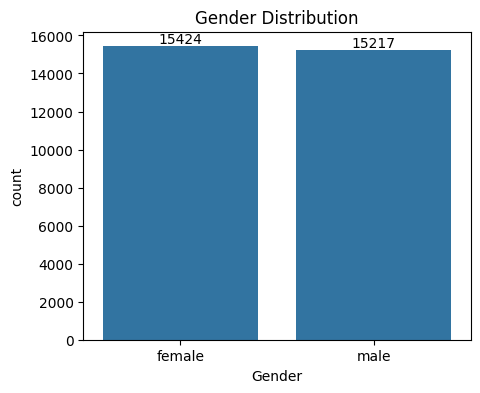

In [11]:
plt.figure(figsize = (5,4))
x = sns.countplot(data = df, x = "Gender")
x.bar_label(x.containers[0])
plt.title("Gender Distribution")
plt.show()

In [12]:
#above graph shows thst no. of females are more than no. of males in the data

### 1. The "Big Three" Correlation

Question: How strongly do Math, Reading, and Writing scores correlate with each other?

Analyst Goal: If a student struggles in Reading, are they statistically guaranteed to struggle in Writing?

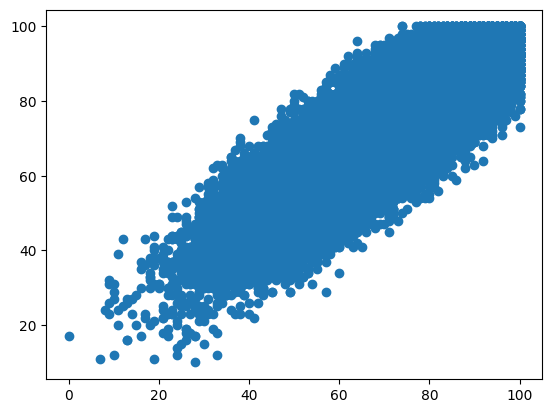

In [13]:
plt.scatter(df['MathScore'],df['ReadingScore'])

In [14]:
df[['WritingScore','ReadingScore','MathScore']].corr()

,WritingScore,ReadingScore,MathScore
WritingScore,1.000000,0.952584,0.807118
ReadingScore,0.952584,1.000000,0.817825
MathScore,0.807118,0.817825,1.000000


<Axes: >

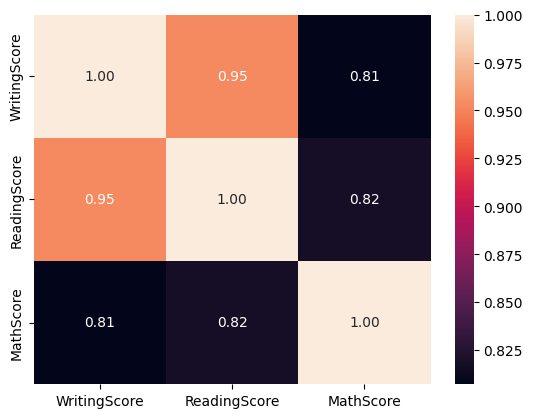

In [15]:
sns.heatmap(df[['WritingScore','ReadingScore','MathScore']].corr(),annot=True,fmt='.2f')

Since, we can see all the 3 categories(subjects) show positive correlation with each other, still, it is clearly visual that reading and riting skills go very much hand in hand as these are both "Literacy" skills. Whereas, subjects like maths requires a different type of logic (Calculation/Spatial) which can be improved by solving different topic-specific questions. 

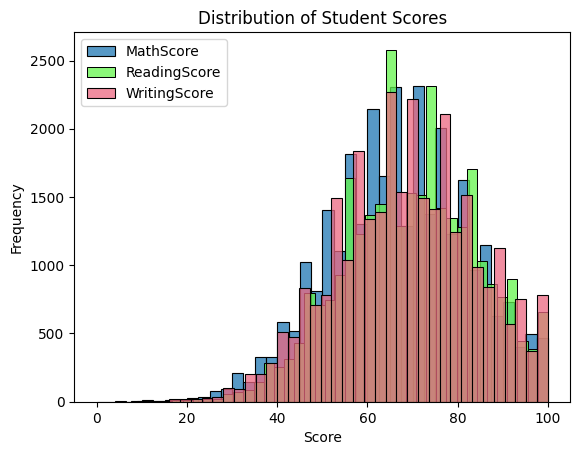

In [16]:
sns.histplot(df['MathScore'],bins=40,label='MathScore')
sns.histplot(df['ReadingScore'],bins=40,label='ReadingScore',color='#65F54C')
sns.histplot(df['WritingScore'],bins=40,label='WritingScore',color='#EB6781')
plt.legend(loc='upper left')
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Student Scores")
plt.show()

### 2. The "Test Prep" Payoff

Question: What is the average score increase for students who completed the TestPrep course versus those who didn't?

Analyst Goal: Prove if the prep course is actually worth the time/money.


In [17]:
df["TestPrep"].value_counts()

TestPrep
none         18856
completed     9955
unknown       1830
Name: count, dtype: int64

In [18]:
df.groupby('TestPrep')[['WritingScore','ReadingScore','MathScore']].mean()

,WritingScore,ReadingScore,MathScore
TestPrep,,,
completed,74.703265,73.732998,69.546660
none,65.092756,67.051071,64.948770
unknown,68.500000,69.655738,66.887978


In [19]:
completed = {'Writing':74.703265, 'Reading':73.732998, 'Math':69.546660}
none = {'Writing':65.092756, 'Reading':67.051071, 'Math':64.948770}

for subject in completed:
    percent=((completed[subject]-none[subject])/none[subject])*100
    x=np.mean(percent)
    print(f'{subject} : {percent:.2f} %')

print(f"avg increase in scores: {x:.2f} %")

Writing : 14.76 %
Reading : 9.97 %
Math : 7.08 %
avg increase in scores: 7.08 %


Students who completed the test preparation course scored approximately 7%–15% higher across different subjects.

On average, we can conclude that a structured preparation strategy improves student performance by nearly 7% overall.

Students categorized under "unknown" test preparation status also tend to score higher than students with no preparation, which may indicate that these students likely received private tutoring or alternative learning support.

### 3. The "Parental Education" Ladder

Question: Does a parent’s education level (e.g., Master's vs. High School) create a "glass ceiling" for student scores?

Analyst Goal: Identify if students from households with lower education levels need extra school-funded resources.


In [20]:
df['ParentEduc'].value_counts()

ParentEduc
some college          6633
high school           5687
associate's degree    5550
some high school      5517
bachelor's degree     3386
master's degree       2023
Name: count, dtype: int64

In [21]:
grouped = df.groupby("ParentEduc").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(grouped)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


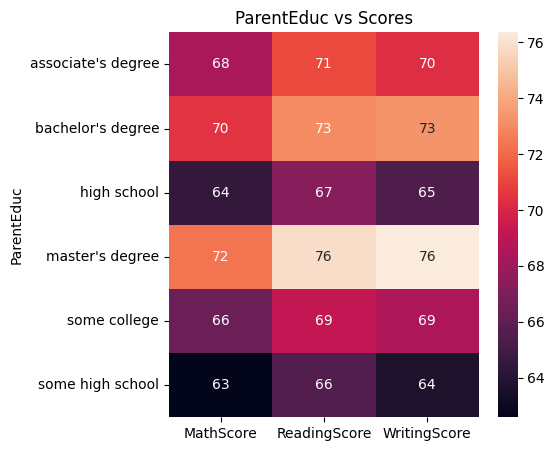

In [22]:
plt.figure(figsize = (5,5))
sns.heatmap(grouped,annot = True)
plt.title("ParentEduc vs Scores")
plt.show()

Higher parental education often correlates with better academic outcomes for students, likely due to increased academic awareness, guidance, and availability of learning resources.Minimum scores in Math are observed among students whose parents have only high school education.

In [23]:
top_scorers=df.groupby(["TestPrep","ParentEduc"]).agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"}).reset_index().sort_values(by='MathScore',ascending=False)
top_scorers.tail()

,TestPrep,ParentEduc,MathScore,ReadingScore,WritingScore
14,unknown,high school,65.679191,67.841040,65.687861
10,none,some college,64.785857,67.099104,65.321962
17,unknown,some high school,62.796923,65.535385,63.664615
8,none,high school,62.791973,64.896269,62.146128
11,none,some high school,60.747780,62.962700,60.002960


We can organize free bootcamps and revision crash courses for students in the “None” and “Unknown” TestPrep categories to help them experience our teaching approach and understand how we support their academic journey through interactive learning, clear explanations, and peer collaboration. This will boost their confidence, understanding, and acedamic performance.

### 4. The "Hungry Student" Factor

Question: How much of a gap exists between students with standard lunch versus free/reduced lunch?

Analyst Goal: Measure the impact of socio-economic status (nutrition/wealth) on academic stamina.


In [24]:
df['LunchType'].value_counts()*100/len(df)

LunchType
standard        64.961979
free/reduced    35.038021
Name: count, dtype: float64

In [25]:
df.groupby(['TestPrep','LunchType']).agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})

MathScore  ReadingScore  WritingScore
TestPrep  LunchType                                          
completed free/reduced  62.030822     68.859589     69.240011
          standard      73.629050     76.380096     77.670749
none      free/reduced  57.184004     61.750378     59.217266
          standard      69.143849     69.914883     68.267113
unknown   free/reduced  58.859223     63.818770     62.032362
          standard      70.981848     72.632013     71.797855

In [26]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings',
       'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore',
       'WritingScore'],
      dtype='object')

In [27]:
df.pivot_table(index='ParentEduc',columns='LunchType',values='MathScore',aggfunc='mean')

LunchType,free/reduced,standard
ParentEduc,,
associate's degree,60.617558,72.669563
bachelor's degree,62.860017,74.604651
high school,56.808713,68.563415
master's degree,64.953333,76.685782
some college,58.760870,70.440342
some high school,54.470988,66.890400


Students whose parents have a Master’s degree and who receive standard lunch show the highest academic performance.

Students whose parents have a Master’s degree but receiving free/reduced lunch still perform well academically, indicating that parental education plays a strong role, even when financial resources are limited.

Students with high school-educated parents and free/reduced lunch demonstrate the lowest scores, due to limited academic guidance and financial constraints.

### 5. The "Study Hours" Sweet Spot
Question: Is there a "diminishing return" on study hours (e.g., do students studying > 10 hours perform significantly better than those doing 5-10)?

Analyst Goal: Find the most efficient amount of study time for the average student.

In [28]:
df.columns

Index(['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
       'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings',
       'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore',
       'WritingScore'],
      dtype='object')

In [29]:
df['WklyStudyHours'].value_counts()

WklyStudyHours
5 - 10    16246
< 5        8238
> 10       5202
Name: count, dtype: int64

<Axes: xlabel='WklyStudyHours', ylabel='Count'>

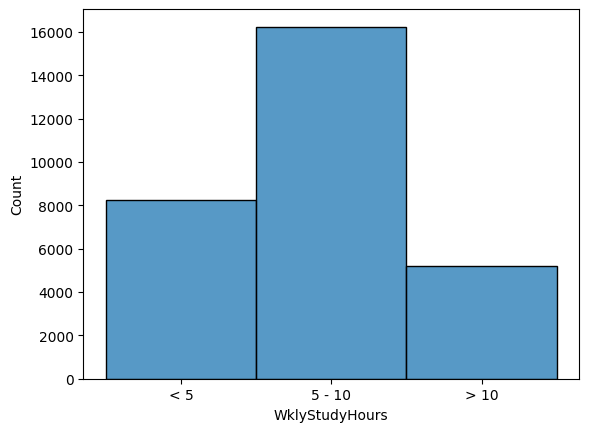

In [30]:
sns.histplot(data=df,x='WklyStudyHours')

In [31]:
df.pivot_table(index='WklyStudyHours',columns='Gender',values={'MathScore','ReadingScore','WritingScore'},aggfunc='mean')

MathScore            ReadingScore            WritingScore  \
Gender             female       male       female       male       female   
WklyStudyHours                                                              
5 - 10          64.506517  69.285057    73.217688  66.027249    73.158850   
< 5             61.930199  67.239543    71.492971  64.848006    71.366457   
> 10            65.976861  71.399770    73.708831  67.042545    74.096413   

                           
Gender               male  
WklyStudyHours             
5 - 10          64.016922  
< 5             62.799368  
> 10            65.485627

Averageof 4-5 marks difference can be seen between marks of students who study more than 10 hours and who study less than 5 hours. It is advised to encourage students to gradually increase their study sessions to atleast 1 hour per day.
    Additionally male students have been performing better than female students in maths and readinga but lag in writing subject. 

### 6. The "First Child" Pressure
Question: Do first-born children (IsFirstChild) perform better than their younger siblings?

Analyst Goal: Explore if family birth order affects academic expectations and results.

In [32]:
df['IsFirstChild'].value_counts()

IsFirstChild
yes    19082
no     10655
Name: count, dtype: int64

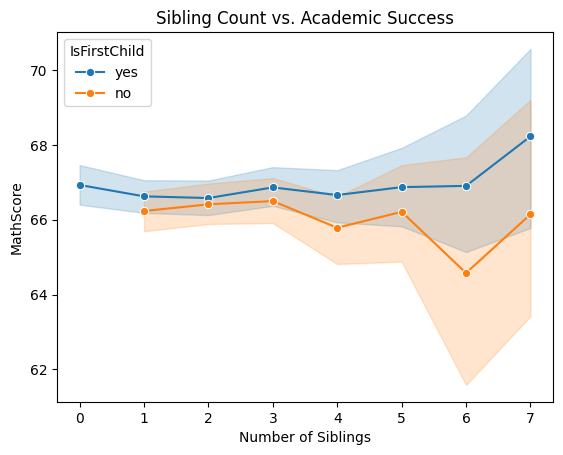

In [35]:
sns.lineplot(data=df, x='NrSiblings', y='MathScore', hue='IsFirstChild', marker='o')

plt.title("Sibling Count vs. Academic Success")
plt.xlabel("Number of Siblings")
plt.show()

The graph shows that students who are single children tend to perform consistently across all exams, maintaining relatively stable scores. In contrast, as the number of siblings increases, there is greater variation in performance. Specifically, a noticeable decline in marks can be observed among students who have six siblings.


### 7. The "Sport-Brain" Connection
Question: Does playing sports regularly improve or hurt MathScore?

Analyst Goal: Determine if extracurricular physical activity correlates with better focus or if it takes too much time away from books.

In [41]:
df['PracticeSport']=df['PracticeSport'].fillna('Unknown')

In [80]:
sports_impact=df.groupby('PracticeSport')[['MathScore','WritingScore','ReadingScore']].mean()
sports_impact

,MathScore,WritingScore,ReadingScore
PracticeSport,,,
Unknown,66.637084,68.519810,69.587956
never,64.171079,66.522727,68.337662
regularly,67.839155,69.604003,69.943019
sometimes,66.274831,68.072438,69.241307


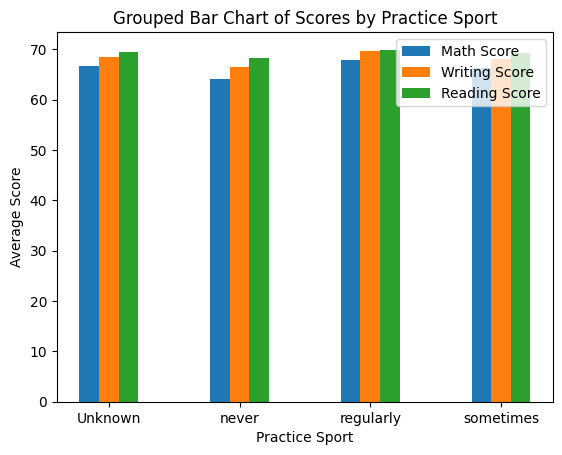

In [83]:
categories=sports_impact.index
x=np.arange(len(categories))
width=0.15
plt.figure()
plt.bar(x-width,sports_impact['MathScore'],width,label='Math Score')
plt.bar(x,sports_impact['WritingScore'],width,label='Writing Score')
plt.bar(x+width,sports_impact['ReadingScore'],width,label='Reading Score')
plt.xticks(x, categories)
plt.xlabel("Practice Sport")
plt.ylabel("Average Score")
plt.title("Grouped Bar Chart of Scores by Practice Sport")
plt.legend()
plt.show()

The graph shows that students who regularly play sports tend to score higher marks compared to students who never participate in sports. This suggests that engaging in sports may help refresh students’ minds, which can improve their concentration levels and overall academic performance.

### 8. Transport & Attendance
Question: Do students using the school_bus have more consistent scores than those with private transport?

Analyst Goal: Look for hidden "logistics" barriers to student performance.

In [89]:
df['TransportMeans'].value_counts()

TransportMeans
school_bus    16145
private       11362
Unknown        3134
Name: count, dtype: int64

In [88]:
df['TransportMeans'].fillna('Unknown',inplace=True)

In [93]:
df.groupby('TransportMeans')[['MathScore','WritingScore','ReadingScore']].mean()

,MathScore,WritingScore,ReadingScore
TransportMeans,,,
Unknown,66.130185,67.708998,68.679962
private,66.511354,68.509593,69.472364
school_bus,66.674636,68.492351,69.446206


Therefore mode of transportation, be it private or school_bus, they do not impact students marks.

# 10. The "Gender Gap" across Subjects
Question: Are female students consistently outperforming males in Reading/Writing while males lead in Math?

Analyst Goal: Verify or debunk common gender stereotypes in education within this specific dataset.

In [101]:
# 1. Separate the two groups
f_prep = df[df['Gender'] == 'female']['MathScore']
m_prep = df[df['Gender'] == 'male']['MathScore']

# 2. Run the T-Test
t_stat, p_val = stats.ttest_ind(f_prep, m_prep)
alpha=0.05
test_df=len(f_prep)+len(m_prep)

crit_t=stats.t.ppf(1-alpha/2,test_df)

print(f"T-Statistic: {t_stat:.4f}")

if t_stat < crit_t:
    print("Result: Not Significant.\n")
else:
    print("Result: Statistically Significant.\n")

print(f"P-Value: {p_val:.4f}")
if p_val > alpha:
    print("Fail to reject H0. No significant difference found.")
else:
    print("Reject H0. Significant difference found.")


T-Statistic: -28.8073
Result: Not Significant.

P-Value: 0.0000
Reject H0. Significant difference found.
